# Energy Consumption Forecasting

This notebook demonstrates a complete time series forecasting pipeline for predicting household energy consumption.

## Objective
To forecast short-term energy usage using historical data and identify the best-performing model.

## Approach
- Data preprocessing and resampling
- Time series modeling using Prophet
- Model evaluation using MAE and RMSE
- Forecast generation with uncertainty intervals

Prophet is selected as the final model based on its superior performance compared to SARIMA.

### 1. Import Libraries

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

### 2. Load Preprocessed Dataset

The dataset has already been cleaned and resampled to hourly frequency.

In [16]:
energy = pd.read_csv('../data/processed/energy_hourly.csv', index_col=0, parse_dates=True)

energy.head()

,Global_active_power
datetime,
2006-12-16 17:00:00,4.222889
2006-12-16 18:00:00,3.632200
2006-12-16 19:00:00,3.400233
2006-12-16 20:00:00,3.268567
2006-12-16 21:00:00,3.056467


### 3. Data Preparation for Prophet

Prophet requires:
- ds → datetime column
- y → target variable

In [17]:
df = energy.reset_index()
df.columns = ['ds', 'y']

### 4. Train-Test Split

The dataset is split into 90% training and 10% testing.

In [18]:
train_size = int(len(df) * 0.9)

train = df[:train_size]
test = df[train_size:]

### 5. Model Training (Prophet)

Prophet is used to capture trend and seasonality automatically.

In [19]:
model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True
)

model.fit(train)

00:52:19 - cmdstanpy - INFO - Chain [1] start processing
00:52:23 - cmdstanpy - INFO - Chain [1] done processing


### 6. Forecast Generation

In [20]:
future = model.make_future_dataframe(periods=len(test), freq='h')
forecast = model.predict(future)

### 7. Model Evaluation

Performance is evaluated using:
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)

In [21]:
forecast_test = forecast.iloc[-len(test):]

mae = mean_absolute_error(test['y'], forecast_test['yhat'])
rmse = np.sqrt(mean_squared_error(test['y'], forecast_test['yhat']))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.49456349999508314
RMSE: 0.6399011808375922


### 8. Prediction Interval Coverage

This measures how often actual values fall within predicted confidence intervals.

In [22]:
coverage = ((test['y'] >= forecast_test['yhat_lower']) & 
            (test['y'] <= forecast_test['yhat_upper'])).mean()

print("Prediction Interval Coverage:", coverage)

Prediction Interval Coverage: 0.8716392020815265


### 9. Forecast Visualization

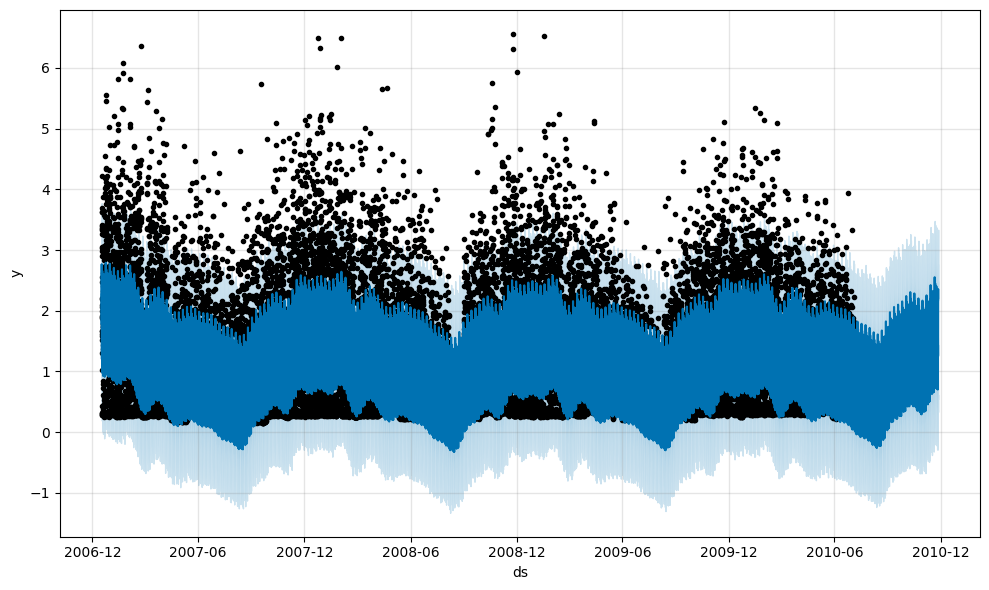

In [23]:
model.plot(forecast);

### 10. Final 24-Hour Forecast

This shows predicted energy consumption for the next 24 hours.

In [24]:
future_24 = model.make_future_dataframe(periods=24, freq='h')
forecast_24 = model.predict(future_24)

forecast_24[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(24)

,ds,yhat,yhat_lower,yhat_upper
31130,2010-07-05 19:00:00,1.379009,0.473998,2.333488
31131,2010-07-05 20:00:00,1.573028,0.646529,2.500616
31132,2010-07-05 21:00:00,1.415865,0.450842,2.382606
31133,2010-07-05 22:00:00,1.000637,0.052632,2.011138
31134,2010-07-05 23:00:00,0.559611,-0.282020,1.498335
31135,2010-07-06 00:00:00,0.270834,-0.758516,1.167144
31136,2010-07-06 01:00:00,0.144355,-0.789129,1.045706
31137,2010-07-06 02:00:00,0.080293,-0.914433,1.047335
31138,2010-07-06 03:00:00,0.019028,-0.954063,0.983972
31139,2010-07-06 04:00:00,0.019858,-0.856453,0.934433


## Key Insights

- Prophet effectively captures daily and weekly seasonality.
- The model achieves lower MAE and RMSE compared to SARIMA.
- Prediction intervals provide reliable uncertainty estimates.
- The model is suitable for short-term energy demand forecasting.

## Business Impact

Accurate energy forecasting helps:
- Optimize energy distribution
- Reduce operational costs
- Improve demand planning
- Enhance sustainability

## Conclusion

This project demonstrates a complete time series forecasting workflow.

Prophet is selected as the final model due to:
- Better performance metrics
- Ability to model seasonality
- Built-in uncertainty estimation

The model can be extended for real-world applications in energy management systems.